In [1]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from datetime import datetime
import pickle, json, sys, os, glob, subprocess
import tables
import pandas as pd
import matplotlib
from scipy.optimize import curve_fit
pd.set_option('display.max_columns', None)

sys.path.insert(0, os.getcwd() + "/../scripts/")
import auxiliar as aux
import geometry as geom

### Paths to data and results

In [2]:
p0a, p0b, p0c = -0.44751321, 3.62502037, -1.43611437
p1a, p1b, p1c = -2.89253919, 0.99443581, -0.34013068

# Root path of this script
root = os.getcwd() + "/"
# Objects directory
root_data = root + "../data/"
root_tmp = root + "tmp/"

# Filename of the total dictionary merged
fname_dcheck_merged = root_data + "datachecks/dict_datachecks_merged.pkl" 
fname_intensity_data = root_data + "datachecks/dict_intensity_data.pkl" 


# Sources ----------------------
# Directory of all the night-wise datachecks
root_dchecks = "/fefs/aswg/workspace/abelardo.moralejo/data/datachecks/night_wise/DL1_datacheck_"

# Flags for computing or not different parts
# Compute the datacheck dictionary
compute_intensity_info = False

process_inline = True
overwrite = False

In [3]:
# Create needed folders
for d in [root_tmp + "get_int/",]:
    os.makedirs(d, exist_ok=True)

### Sending jobs with N datachecks to read inside

In [4]:
str_dchecks = "datacheck_"
dl1_root = "/fefs/aswg/data/real/DL1/*/v0.*/tailcut84/"
main_name = f"{str_dchecks}dl1_LST-1.Run?????"
total_dl1a_runwise = np.sort(
    glob.glob(
        dl1_root + "*/" + f"{main_name}.h5") + glob.glob(dl1_root + f"{main_name}.h5")
)

lengroups = 100
print(f"Amount of jobs is {np.ceil(len(total_dl1a_runwise) / lengroups):.0f}")

njobs = int(np.ceil(len(total_dl1a_runwise) / lengroups))

Amount of jobs is 137


In [5]:
%%time
if compute_intensity_info == True:
    for n in range(njobs)[:]:
        print(f"Getting intensity... {n}/{njobs}") if process_inline else None
        
        im = n * lengroups
        iM = (n + 1) * lengroups if (n + 1) * lengroups < len(total_dl1a_runwise) else len(total_dl1a_runwise)
        
        fname = root_tmp + "get_int/" + f"get_int_{im}_{iM}.pkl"
        string = f"{im} {iM} {fname} {lengroups}"
    
        # --- Overwritting logic --- #
        query_files = glob.glob(fname)
        if not overwrite and len(query_files) > 0:
            print(f"\nFile for {im}-{iM} already exists.")
            continue # If condition is fulfilled we skip this iteration of loop
        elif overwrite and len(query_files) > 0:
            print(f"\nFile for {im}-{iM} already exists.\nOverwriting...")
            os.remove(file) # Removing file 
        
        
        # Then we call the dl1_to_dl2 function in the dataprocessing_script.py
        python_command = f"python {root}script_datachecks.py get_and_write_intensities {string}"

        str_output = f"-o ./tmp/slurm_output/get_intensities_{im}_{iM}.out"
        slurm_command = f"sbatch -p short -J get_intensities_{im}_{iM} {str_output} --wrap='{python_command}'"

        command = python_command if process_inline else slurm_command
        subprocess.run(command, shell=True, text=True)

CPU times: user 10 μs, sys: 11 μs, total: 21 μs
Wall time: 27.4 μs


In [6]:
# Some slurm commands
# !squeue -u juan.jimenez
# !scancel -u juan.jimenez 
# !seff 37423162

### <span style="color:red;">------------------------------------------------------------------------------------------------------------------</span>
### <span style="color:red;">------------------------------------------------------------------------------------------------------------------</span>

### <span style="color:red;"> Wait untill the jobs are processed and then the results need to be fully stored </span>
### <span style="color:red;">------------------------------------------------------------------------------------------------------------------</span>
### <span style="color:red;">------------------------------------------------------------------------------------------------------------------</span>
#### Putting the information in a unique file

In [7]:
%%time
if compute_intensity_info:
    intensity_counts, intensity_points = [], []

    files = np.sort(glob.glob(root_tmp + "get_int/*.pkl"))

    for i, file in enumerate(files):
        print(i, "/", len(files))

        with open(file, "rb") as f:
            _data_ = pickle.load(f)
        _i_, _c_ = _data_
        intensity_counts = intensity_counts + _c_
        intensity_points = intensity_points + _i_
    
    # Saving the objects in the objects directory
    with open(fname_intensity_data, "wb") as f:
        pickle.dump([intensity_counts, intensity_points], f, pickle.HIGHEST_PROTOCOL)  
else:
    # To read the file:
    with open(fname_intensity_data, "rb") as f:
            intensity_counts, intensity_points = pickle.load(f)

CPU times: user 39.3 s, sys: 17 s, total: 56.4 s
Wall time: 1min 3s


In [8]:
str_dchecks = "datacheck_"
dl1_root = "/fefs/aswg/data/real/DL1/*/v0.*/tailcut84/"
main_name = f"{str_dchecks}dl1_LST-1.Run?????"
total_dl1a_runwise = np.sort(
    glob.glob(dl1_root + "*/" + f"{main_name}.h5") + 
    glob.glob(dl1_root + f"{main_name}.h5")
)

tab = tables.open_file(total_dl1a_runwise[0])

binstab = tab.root.dl1datacheck.histogram_binning.col("hist_intensity")[0]
tab.close()

##### Reading the already computed dictionaries

In [9]:
# To read the file:
with open(fname_dcheck_merged, "rb") as f:
        dict_dcheck_merged = pickle.load(f)   

## Plotting full intensity plots

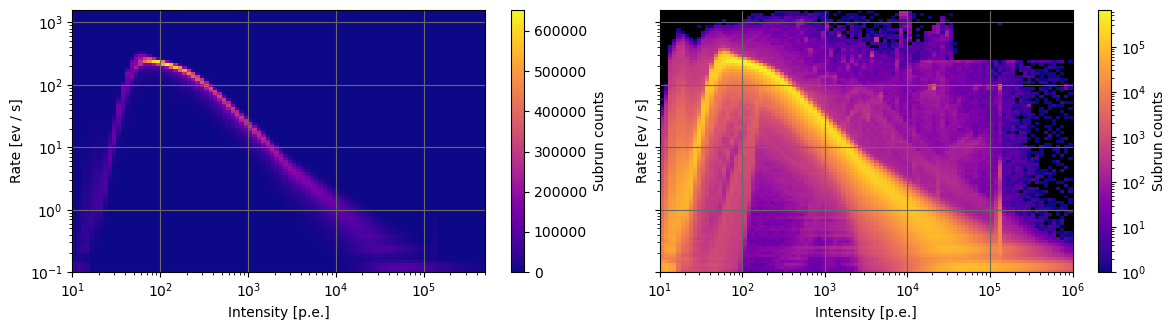

In [10]:
N = 90
bins = (binstab, np.logspace(-1, 3.2, N))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)

hist1 = ax1.hist2d(intensity_points, intensity_counts, bins,cmap="plasma", )
hist2 = ax2.hist2d(intensity_points, intensity_counts, bins, norm=matplotlib.colors.LogNorm(), cmap="plasma")

fig.colorbar(hist1[3], label="Subrun counts")
fig.colorbar(hist2[3], label="Subrun counts")

for ax in [ax1, ax2]:
    ax.set_facecolor("k"); ax.grid(color="dimgray"); ax.loglog()
    ax.set_xlabel("Intensity [p.e.]"); ax.set_ylabel("Rate [ev / s]")
ax1.set_xlim(1e1, 5e5)

fig.tight_layout()
plt.savefig(f"plots/plot_intensity_total.png", bbox_inches="tight", dpi=300)
plt.show()

## Intensity spectrum parameters ZD corrections

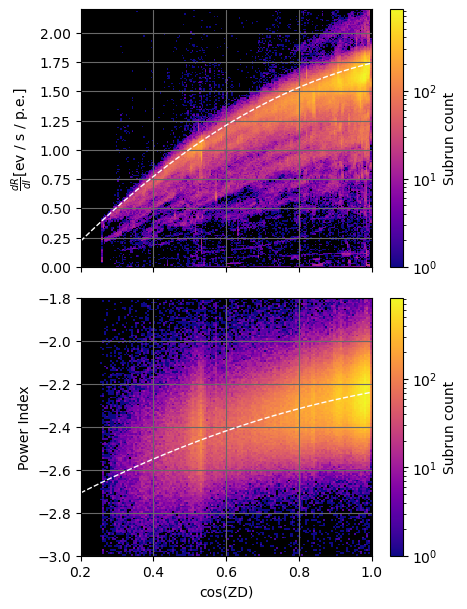

In [11]:
nanmask = np.isnan(dict_dcheck_merged["cosmics_rate_at_422_pe"])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4.5, 6), sharex=True)
hist1 = ax1.hist2d(
    np.cos(np.deg2rad(dict_dcheck_merged["zd"]))[~nanmask], 
    np.array(dict_dcheck_merged["cosmics_rate_at_422_pe"])[~nanmask], 
    bins=(np.linspace(0.2, 1, 200), np.linspace(0, 2.2, 200)),
    norm=matplotlib.colors.LogNorm(),
    cmap="plasma"
)

hist2 = ax2.hist2d(
    np.cos(np.deg2rad(dict_dcheck_merged["zd"]))[~nanmask], 
    np.array(dict_dcheck_merged["cosmics_spectral_index"])[~nanmask], 
    bins=(np.linspace(0.2, 1, 150), np.linspace(-3, -1.8, 150)),
    norm=matplotlib.colors.LogNorm(),
    cmap="plasma"
)
fig.colorbar(hist1[3], label="Subrun count")
fig.colorbar(hist2[3], label="Subrun count")
for ax in [ax1, ax2]:
    ax.set_facecolor("k"); ax.grid(color="dimgray")
fig.tight_layout()
ax2.set_xlabel("cos(ZD)"); ax2.set_ylabel("Power Index")
ax1.set_ylabel("$\\frac{dR}{dI}$[ev / s / p.e.]")

x_fit = np.linspace(0.2, 1, 100)
y_fit1 = geom.quadratic_func(x_fit, p0a, p0b, p0c)
y_fit2 = geom.quadratic_func(x_fit, p1a, p1b, p1c)
ax1.plot(x_fit, y_fit1, 'w', lw=1, ls="--")
ax2.plot(x_fit, y_fit2, 'w', lw=1, ls="--")

plt.savefig(f"plots/plot_int_parameters_zd_correction.png", bbox_inches="tight", dpi=300)
plt.show()

## Corner parameter space plot
* Peak rate / Half peak intensity / PWL rate / PWL index / RA / DEC / az / dec / NSB

In [12]:
labels_multiplot = [
    "zd",
    "az",
    "ra",
    "dec",
    "charge_mean",
    "light_yield",
    "cosmics_peak_rate",
    "intensity_at_half_peak_rate",
    "cosmics_spectral_index",
    "cosmics_rate_at_422_pe",
    "intensity_spectrum_fit_p_value"
]

data_multiplot = [
    np.cos(np.deg2rad(dict_dcheck_merged["zd"])),
    dict_dcheck_merged["az"],
    dict_dcheck_merged["charge_mean"],
    dict_dcheck_merged["light_yield"],
    dict_dcheck_merged["cosmics_peak_rate"],
    dict_dcheck_merged["intensity_at_half_peak_rate"],
    dict_dcheck_merged["cosmics_spectral_index"],
    dict_dcheck_merged["cosmics_rate_at_422_pe"],
]

labels_multiplot = [
    "cos(ZD)",
    "AZ [deg]",
    "NSB [p.e.]",
    "LY",
    "Cosmics peak\nrate [ev/s/p.e.]",
    "I @ 1/2 peak\nrate [p.e.]",
    "spectral index",
    "$\\frac{dR}{dI}$ [ev/s/p.e.]",
]

Nbins = 150
bins_multiplot = [
    np.linspace(0.2, 1, Nbins),
    np.linspace(0, 360, Nbins),
    np.linspace(1, 6, Nbins),
    np.linspace(0, 1.5, Nbins),
    np.linspace(0, 80, Nbins),
    np.linspace(20, 80, Nbins),
    np.linspace(-3, -1, Nbins),
    np.linspace(0, 2.5, Nbins),
]

ticks_multiplot = [
    [0.25, 0.5, 0.75],
    [100, 200, 300],
    [2, 3, 4, 5],
    [0.25, 0.75, 1.25],
    [20, 40, 60],
    [30, 50, 70], 
    [-2.5, -2, -1.5],
    [0.5, 1, 1.5, 2],
]

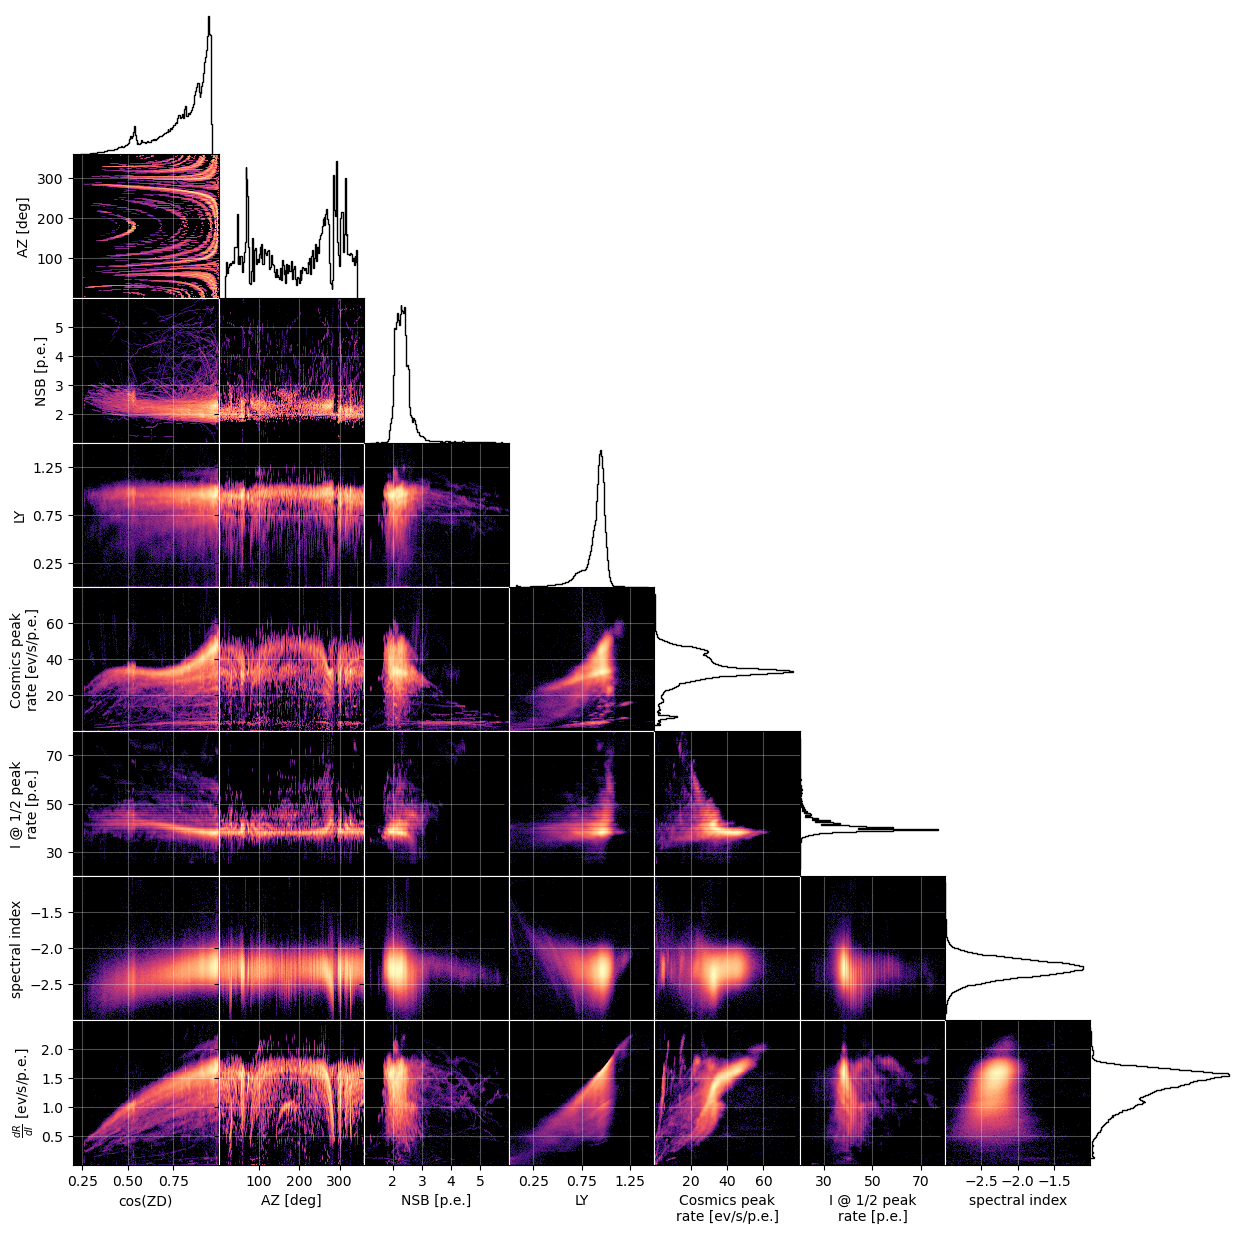

In [13]:
fig, ax = plt.subplots(len(bins_multiplot), len(bins_multiplot), figsize=(15, 15),)

for i in range(len(ax)):
    for j in range(len(ax[i])):


        x, y = np.array(data_multiplot[j]), np.array(data_multiplot[i])
        nanmask = ~(np.isnan(x) | np.isnan(y))
        
        if j > i:
            ax[i][j].set_axis_off()
        elif j == i:
            ax[i][j].set_axis_off()
            if i >= len(ax) / 2:
                ax[i][j].hist(x[nanmask], bins=bins_multiplot[i], 
                              histtype="step", orientation="horizontal", color="k")
            else:
                ax[i][j].hist(x[nanmask], bins=bins_multiplot[i], histtype="step", color="k")

        else:
            ax[i][j].hist2d(x[nanmask], 
                            y[nanmask], 
                            bins=(bins_multiplot[j], bins_multiplot[i]), 
                            norm=matplotlib.colors.LogNorm(), 
                            cmap="magma"
                            )
            ax[i][j].set_facecolor("k")
            ax[i][j].grid(color="w", alpha=0.3)

            ax[i][j].spines['bottom'].set_color("w")
            ax[i][j].spines['top'].set_color("w") 
            ax[i][j].spines['right'].set_color("w")
            ax[i][j].spines['left'].set_color("w")

            ax[i][j].set_xticks(ticks_multiplot[j])
            ax[i][j].set_yticks(ticks_multiplot[i])
            
        if j - i == -1 :
            ax[i][j].spines['top'].set_color("k") 
            ax[i][j].spines['right'].set_color("k")
        if i != (len(ax)- 1):
            ax[i][j].set_xticklabels([])
        else:
            ax[i][j].spines['bottom'].set_color("k")
            ax[i][j].set_xlabel(labels_multiplot[j])
            
        if j != 0:
            ax[i][j].set_yticklabels([])
        else:
            ax[i][j].spines['left'].set_color("k")
            ax[i][j].set_ylabel(labels_multiplot[i])

plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig(root + f"plots/plot_corner_intensity.png", bbox_inches="tight", dpi=400)
plt.show()